In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load data (PASTE YOUR COPIED FILE PATH HERE)
df = pd.read_csv('/kaggle/input/datasets/gyaanluthria/enterprise-sales/Enterprise_Sales_Financial_Data.csv')

# 2. Check structure
print("--- DATA STRUCTURE ---")
df.info()

# 3. Quick Math
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

# 4. Count Categories
print("\n--- CATEGORY COUNTS ---")
print(df['ProductCategory'].value_counts())

--- DATA STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           10000 non-null  int64  
 1   OrderDate         10000 non-null  object 
 2   Region            10000 non-null  object 
 3   CustomerSegment   10000 non-null  object 
 4   ProductCategory   10000 non-null  object 
 5   SalesChannel      10000 non-null  object 
 6   UnitsSold         10000 non-null  int64  
 7   UnitPrice         10000 non-null  int64  
 8   UnitCost          10000 non-null  int64  
 9   TotalRevenue      10000 non-null  int64  
 10  TotalCost         10000 non-null  int64  
 11  TotalProfit       10000 non-null  int64  
 12  ProfitMargin_Pct  10000 non-null  float64
dtypes: float64(1), int64(7), object(5)
memory usage: 1015.8+ KB

--- STATISTICAL SUMMARY ---


,OrderID,UnitsSold,UnitPrice,UnitCost,TotalRevenue,TotalCost,TotalProfit,ProfitMargin_Pct
count,1.000000e+04,10000.000000,10000.00000,10000.00000,10000.00000,10000.000000,10000.000000,10000.00000
mean,1.005000e+06,24.506400,321.75530,176.45150,7878.77740,4320.923400,3557.854000,45.44292
std,2.886896e+03,9.940726,274.78817,159.21069,7937.80473,4564.394174,3786.286993,11.66340
min,1.000000e+06,1.000000,42.00000,14.00000,43.00000,15.000000,13.000000,25.10000
25%,1.002500e+06,18.000000,53.00000,31.00000,1434.00000,768.000000,651.000000,35.30000
50%,1.005000e+06,24.000000,250.00000,134.00000,5502.00000,2856.000000,2304.000000,45.40000
75%,1.007499e+06,31.000000,640.00000,278.00000,11346.00000,6118.000000,5133.250000,55.70000
max,1.009999e+06,64.000000,862.00000,639.00000,45684.00000,29400.000000,27132.000000,66.70000



--- CATEGORY COUNTS ---
ProductCategory
Cloud Services         3479
Enterprise Software    2969
Server Hardware        2531
Consulting             1021
Name: count, dtype: int64


**Initial Observation:** The dataset contains 10,000 records with perfectly clean data (0 missing values). The average Total Profit per order is $3,557. Cloud Services is our most frequently sold product category.

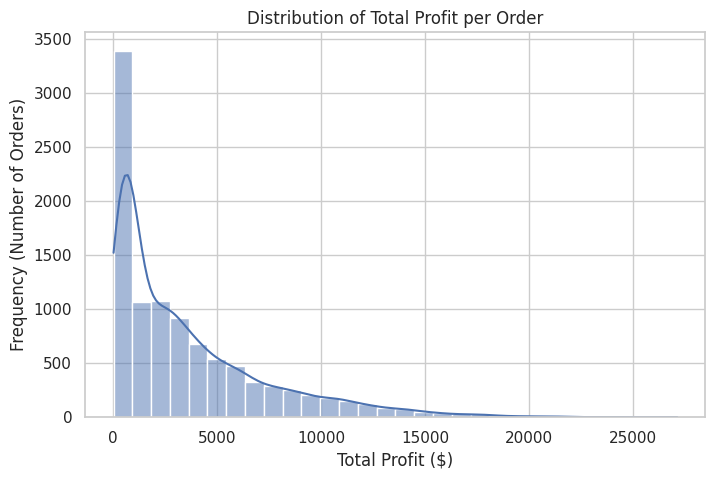

In [4]:
# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalProfit'], bins=30, kde=True)
plt.title('Distribution of Total Profit per Order')
plt.xlabel('Total Profit ($)')
plt.ylabel('Frequency (Number of Orders)')
plt.show()

**Histogram Observation:** The profit distribution is right-skewed. Most orders generate modest profits under $5,000, while a long tail represents rare, massive enterprise deals extending past $20,000.

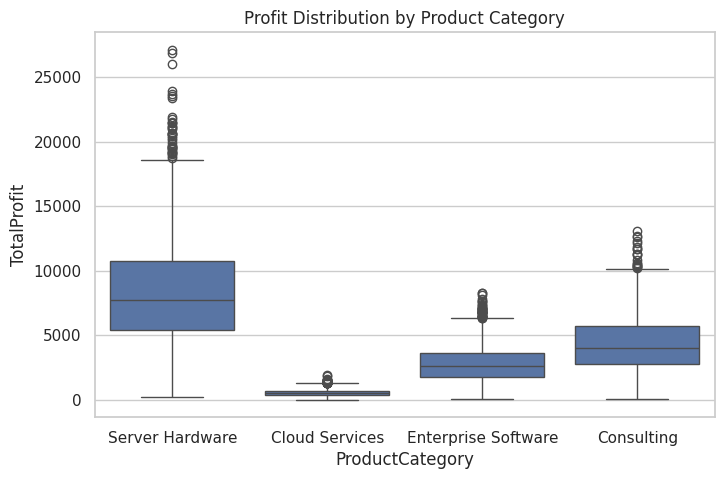

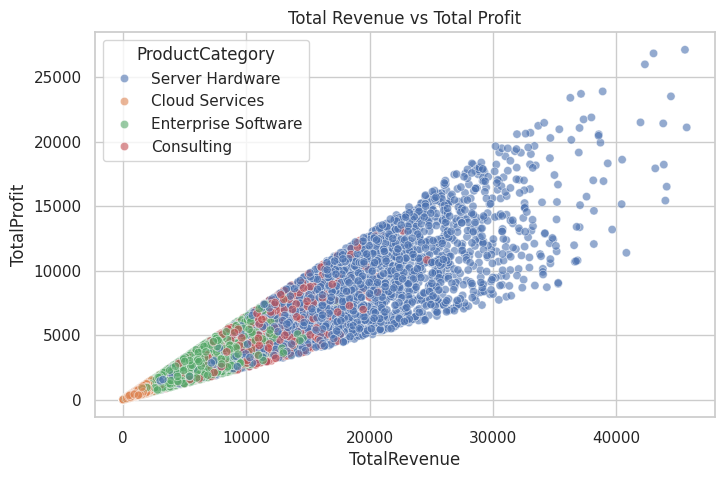

In [5]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='ProductCategory', y='TotalProfit', data=df)
plt.title('Profit Distribution by Product Category')
plt.show()

# Scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='TotalRevenue', y='TotalProfit', hue='ProductCategory', data=df, alpha=0.6)
plt.title('Total Revenue vs Total Profit')
plt.show()

**Bivariate Observation:** * **Boxplot:** Enterprise Software and Server Hardware generate higher median profits and contain the highest outlier deals.
* **Scatterplot:** There is a strict linear relationship between Revenue and Profit, separated into distinct "bands" based on specific product margins.

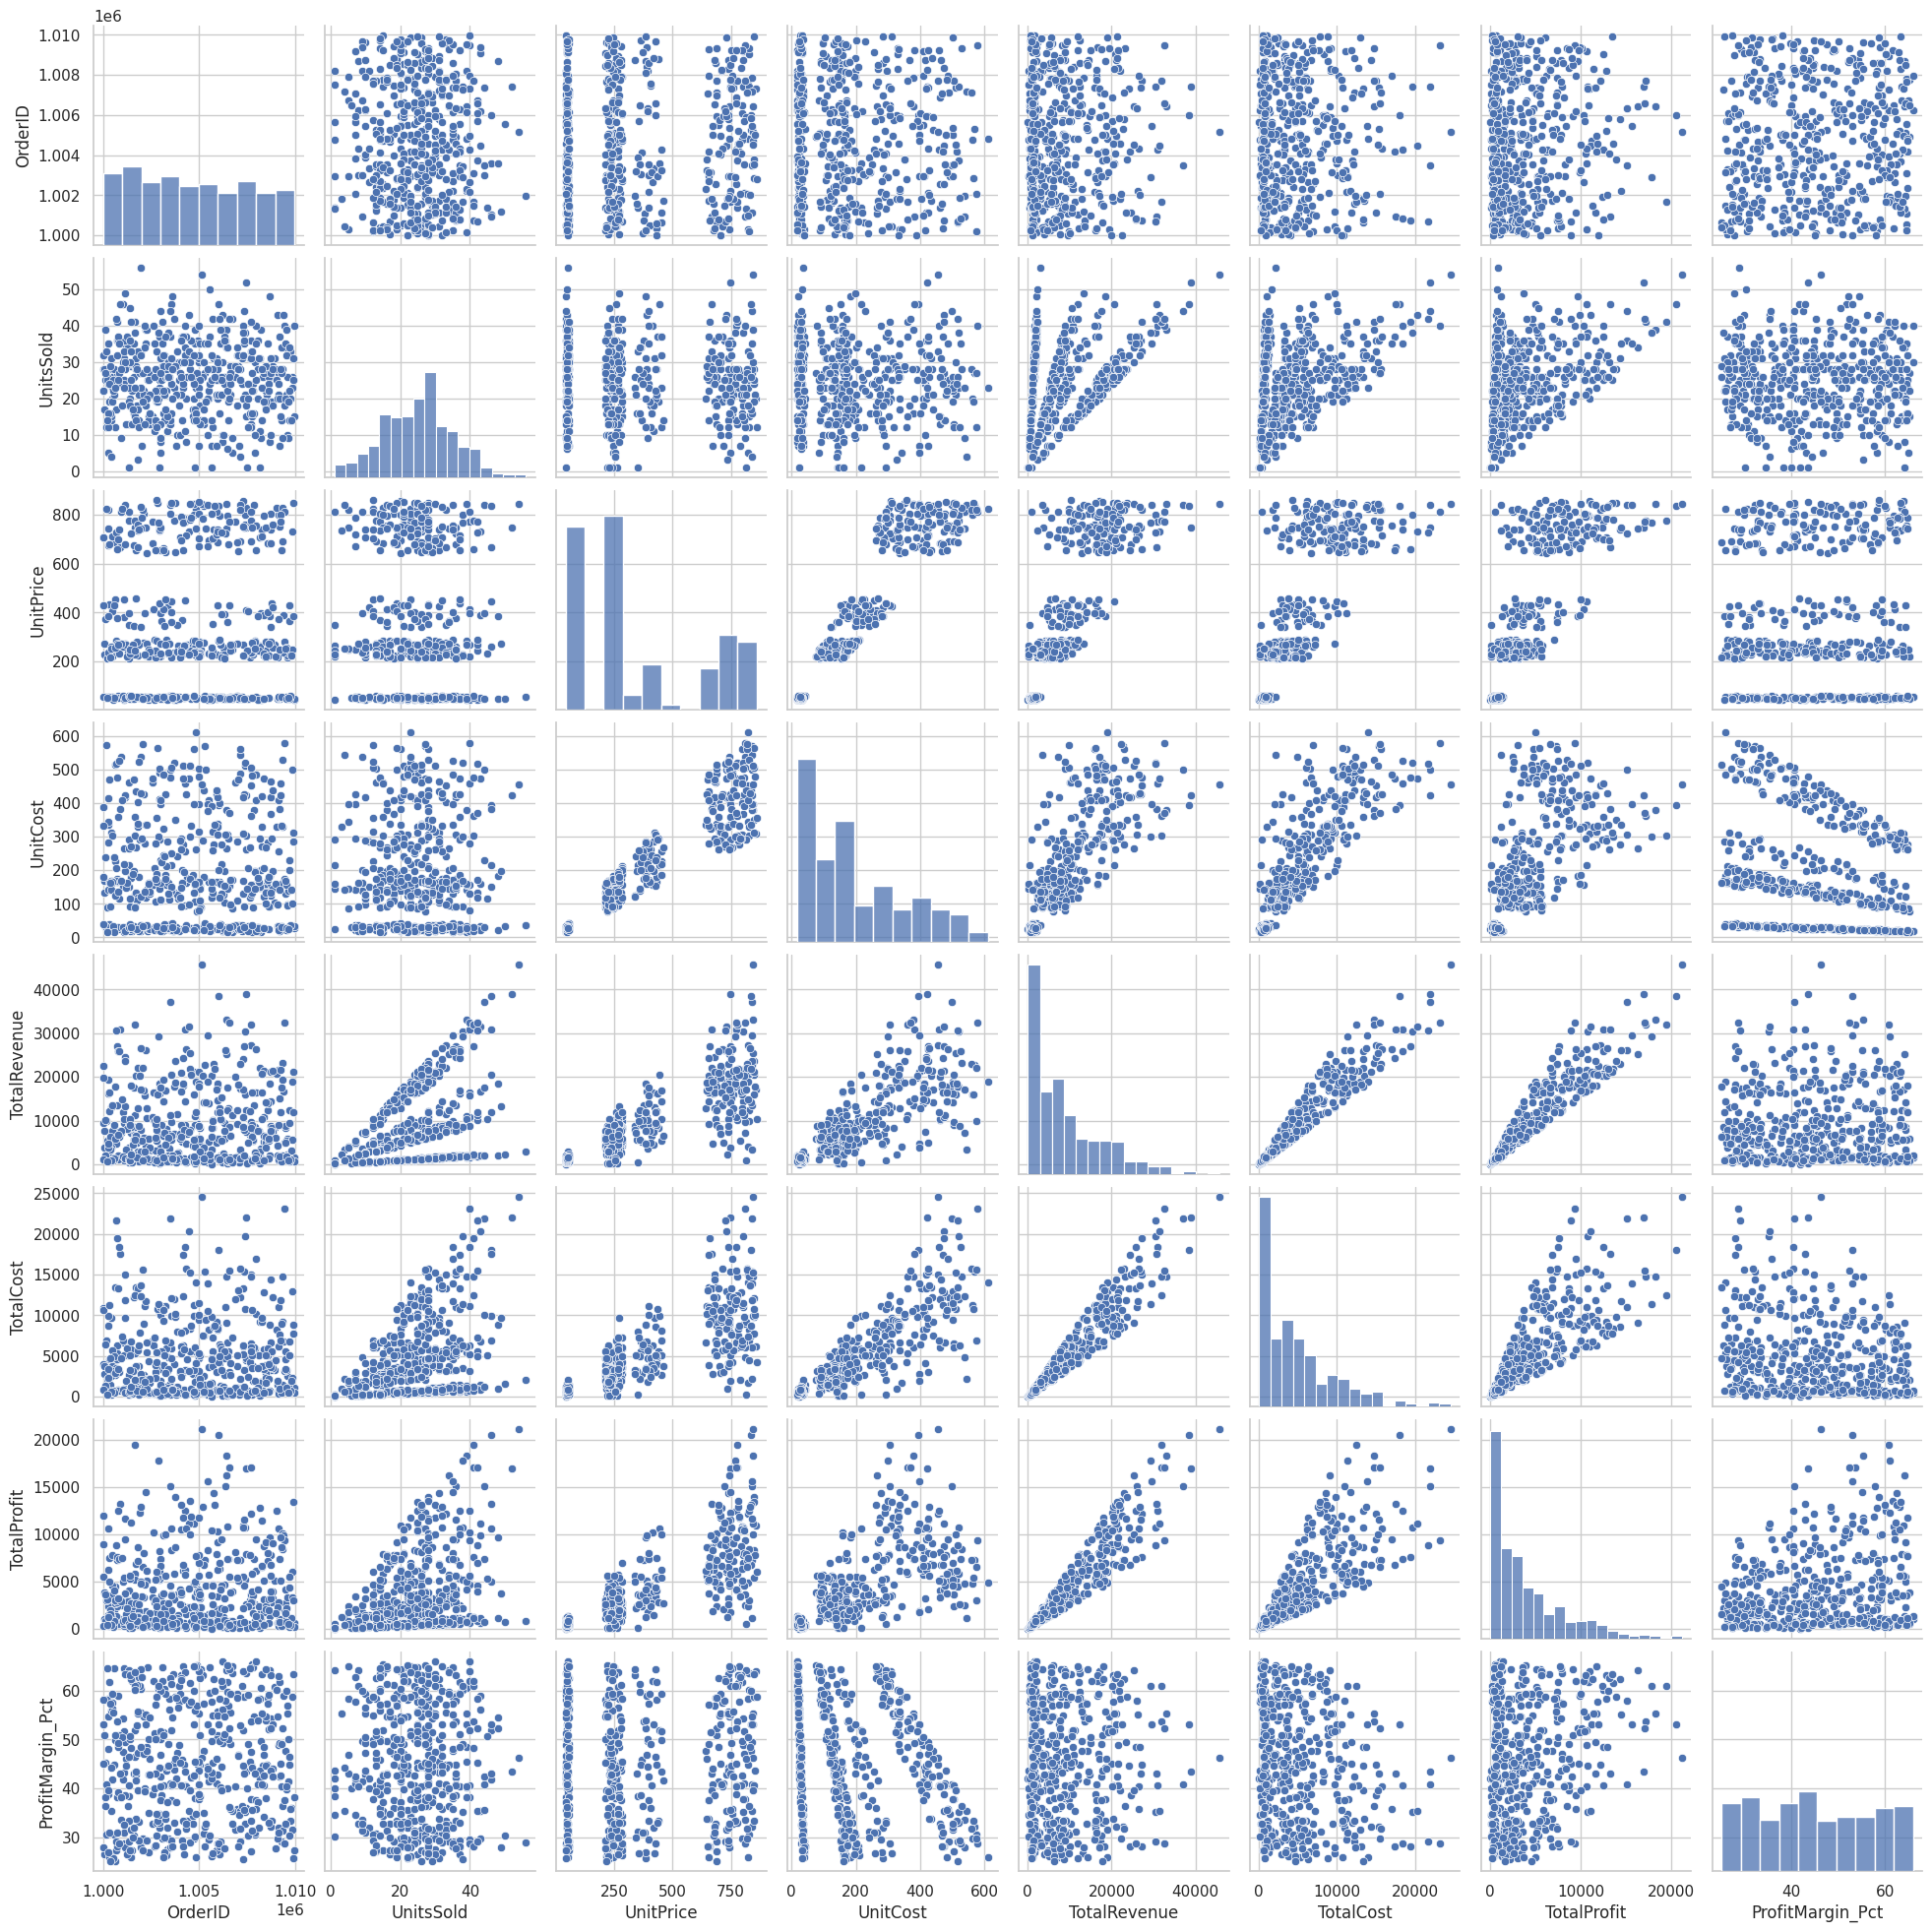

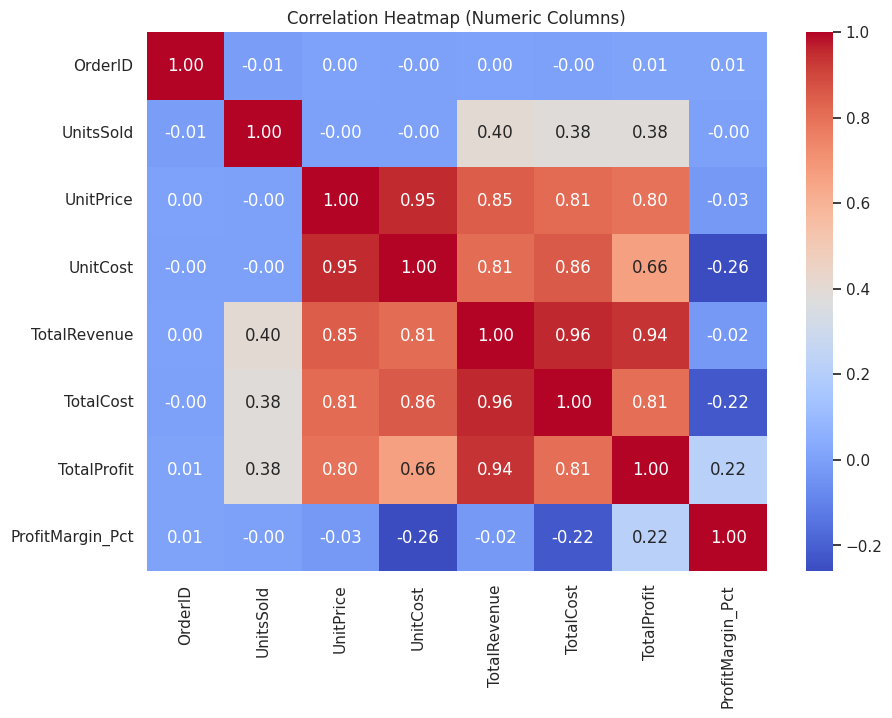

In [7]:
# Filter to only numeric columns to prevent errors
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Pairplot (Sampled to prevent Kaggle from lagging)
sns.pairplot(numeric_df.sample(n=500, random_state=42))
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numeric Columns)')
plt.show()

### Final Summary of Findings
1. **Data Quality:** The dataset is incredibly robust with no missing values to clean.
2. **Product Profitability:** While Cloud Services drives high volume, Enterprise Software and Server Hardware are the true drivers of massive profit spikes.
3. **Financial Correlations:** The heatmap reveals that Total Profit correlates strongly with Revenue (0.91), but surprisingly weakly with Units Sold (0.28). This proves that selling high-margin products is far more important to the bottom line than simply pushing high unit volume.